# EDA Refatorada — Detecção de Fraude em Transações Financeiras

**Projeto:** Detecção de Fraude em Transações Financeiras com PaySim  
**Entregável:** Notebook de EDA  
**Objetivo deste notebook:** realizar uma análise exploratória organizada, alinhada à proposta formal do projeto, para apoiar as decisões de pré-processamento e modelagem.

Este notebook não tem como objetivo treinar modelos finais.  
Ele serve para responder perguntas como:

1. Qual é o nível de desbalanceamento do dataset?
2. Quais tipos de transação concentram fraudes?
3. Quais variáveis podem gerar risco de *data leakage*?
4. A coluna `isFlaggedFraud` funciona como detector?
5. Existem inconsistências lógicas nas variáveis de saldo?
6. O comportamento temporal em `step` pode ser explorado?
7. Quais decisões devem ser levadas para o notebook de pré-processamento?

## Decisão de escopo

O projeto não busca apenas "a maior acurácia possível".  
O foco é avaliar soluções que tenham bom desempenho na classe fraude, mas que também possam ser viáveis em um cenário de transação rápida.

Por isso, esta EDA já prepara o caminho para avaliar posteriormente:

- desempenho na classe minoritária;
- robustez ao desbalanceamento;
- risco de falsos positivos e falsos negativos;
- tempo de inferência;
- custo total das decisões.

## 1. Importações e configurações

As bibliotecas abaixo são usadas apenas para análise exploratória, visualização e organização dos resultados.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

## 2. Carregamento do dataset

O dataset usado é o **PaySim Synthetic Financial Dataset**, disponível no Kaggle.


In [2]:
# Opção 1: caminho local do arquivo CSV.
# Altere este caminho caso o arquivo já esteja salvo no seu computador.
CAMINHO_CSV = None
# Exemplo:
# CAMINHO_CSV = "data/PS_20174392719_1491204439457_log.csv"

# Opção 2: baixar pelo KaggleHub.
USAR_KAGGLEHUB = True

if CAMINHO_CSV is not None:
    caminho_csv = Path(CAMINHO_CSV)
else:
    if USAR_KAGGLEHUB:
        try:
            import kagglehub

            caminho_dataset = Path(kagglehub.dataset_download("ealaxi/paysim1"))
            arquivos_csv = list(caminho_dataset.glob("*.csv"))

            if not arquivos_csv:
                raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta baixada pelo KaggleHub.")

            caminho_csv = arquivos_csv[0]
        except Exception as erro:
            raise RuntimeError(
                "Não foi possível carregar pelo KaggleHub. "
                "Baixe o dataset manualmente e informe o caminho em CAMINHO_CSV."
            ) from erro
    else:
        raise ValueError("Informe CAMINHO_CSV ou defina USAR_KAGGLEHUB=True.")

print(f"Arquivo carregado: {caminho_csv}")
df = pd.read_csv(caminho_csv)

df.head()

100%|██████████| 178M/178M [00:08<00:00, 23.1MB/s]

Extracting files...


Arquivo carregado: /root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2/PS_20174392719_1491204439457_log.csv


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


## 3. Visão geral da base

Nesta seção, verificamos tamanho, colunas, tipos de dados, memória utilizada e primeiras estatísticas gerais.

Essa etapa ajuda a entender se a base é compatível com o escopo do projeto e se haverá necessidade de otimização antes da modelagem.

In [3]:
def tamanho_memoria(dataframe: pd.DataFrame) -> str:
    memoria_mb = dataframe.memory_usage(deep=True).sum() / (1024 ** 2)
    return f"{memoria_mb:,.2f} MB"

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]:,}")
print(f"Uso aproximado de memória: {tamanho_memoria(df)}")

display(df.info())
display(df.head())

Linhas: 6,362,620
Colunas: 11
Uso aproximado de memória: 1,452.57 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


None

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [4]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,"6,362,620.0000",243.3972,142.3320,1.0000,156.0000,239.0000,335.0000,743.0000
amount,"6,362,620.0000","179,861.9035","603,858.2315",0.0000,"13,389.5700","74,871.9400","208,721.4775","92,445,516.6400"
oldbalanceOrg,"6,362,620.0000","833,883.1041","2,888,242.6730",0.0000,0.0000,"14,208.0000","107,315.1750","59,585,040.3700"
newbalanceOrig,"6,362,620.0000","855,113.6686","2,924,048.5030",0.0000,0.0000,0.0000,"144,258.4100","49,585,040.3700"
oldbalanceDest,"6,362,620.0000","1,100,701.6665","3,399,180.1130",0.0000,0.0000,"132,705.6650","943,036.7075","356,015,889.3500"
newbalanceDest,"6,362,620.0000","1,224,996.3982","3,674,128.9421",0.0000,0.0000,"214,661.4400","1,111,909.2500","356,179,278.9200"
isFraud,"6,362,620.0000",0.0013,0.0359,0.0000,0.0000,0.0000,0.0000,1.0000
isFlaggedFraud,"6,362,620.0000",0.0000,0.0016,0.0000,0.0000,0.0000,0.0000,1.0000


In [5]:
# Tipos de dados por coluna
pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "n_unicos": df.nunique().values,
    "exemplo": [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

,coluna,tipo,n_unicos,exemplo
0,step,int64,743,1
1,type,object,5,PAYMENT
2,amount,float64,5316900,"9,839.6400"
3,nameOrig,object,6353307,C1231006815
4,oldbalanceOrg,float64,1845844,"170,136.0000"
5,newbalanceOrig,float64,2682586,"160,296.3600"
6,nameDest,object,2722362,M1979787155
7,oldbalanceDest,float64,3614697,0.0000
8,newbalanceDest,float64,3555499,0.0000
9,isFraud,int64,2,0


### Leitura esperada desta seção

O PaySim possui grande volume de transações e poucas variáveis.  
As colunas `nameOrig` e `nameDest` são identificadores de alta cardinalidade.  
A variável alvo é `isFraud`, enquanto `isFlaggedFraud` representa uma regra/sinalização própria do simulador e não deve ser usada diretamente como feature principal.

## 4. Qualidade estrutural dos dados

Aqui verificamos:

- valores ausentes;
- registros duplicados;
- consistência básica da variável alvo;
- presença das colunas esperadas.

In [6]:
colunas_esperadas = [
    "step", "type", "amount",
    "nameOrig", "oldbalanceOrg", "newbalanceOrig",
    "nameDest", "oldbalanceDest", "newbalanceDest",
    "isFraud", "isFlaggedFraud"
]

colunas_faltantes = [col for col in colunas_esperadas if col not in df.columns]
colunas_extras = [col for col in df.columns if col not in colunas_esperadas]

print("Colunas faltantes:", colunas_faltantes)
print("Colunas extras:", colunas_extras)

Colunas faltantes: []
Colunas extras: []


In [7]:
# Valores ausentes
nulos = df.isna().sum().sort_values(ascending=False)
percentual_nulos = (df.isna().mean() * 100).sort_values(ascending=False)

tabela_nulos = pd.DataFrame({
    "nulos": nulos,
    "percentual": percentual_nulos
})

tabela_nulos

,nulos,percentual
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [8]:
# Duplicatas
duplicatas = df.duplicated().sum()

print(f"Duplicatas: {duplicatas:,}")
print(f"Percentual de duplicatas: {duplicatas / len(df):.6%}")

Duplicatas: 0
Percentual de duplicatas: 0.000000%


In [9]:
# Valores possíveis da variável alvo
df["isFraud"].value_counts(dropna=False).rename_axis("isFraud").reset_index(name="quantidade")

,isFraud,quantidade
0,0,6354407
1,1,8213


## 5. Análise da variável alvo e do desbalanceamento


In [10]:
contagem_alvo = df["isFraud"].value_counts().sort_index()
proporcao_alvo = df["isFraud"].value_counts(normalize=True).sort_index()

resumo_alvo = pd.DataFrame({
    "classe": ["Legítima", "Fraude"],
    "quantidade": [contagem_alvo.get(0, 0), contagem_alvo.get(1, 0)],
    "proporcao": [proporcao_alvo.get(0, 0), proporcao_alvo.get(1, 0)]
})

qtd_legitimas = contagem_alvo.get(0, 0)
qtd_fraudes = contagem_alvo.get(1, 0)
imbalance_ratio = qtd_legitimas / qtd_fraudes if qtd_fraudes > 0 else np.inf

display(resumo_alvo)

print(f"Quantidade de transações legítimas: {qtd_legitimas:,}")
print(f"Quantidade de fraudes: {qtd_fraudes:,}")
print(f"Taxa de fraude: {qtd_fraudes / len(df):.6%}")
print(f"Imbalance Ratio aproximado: 1 fraude para cada {imbalance_ratio:,.2f} transações legítimas")

,classe,quantidade,proporcao
0,Legítima,6354407,0.9987
1,Fraude,8213,0.0013


Quantidade de transações legítimas: 6,354,407
Quantidade de fraudes: 8,213
Taxa de fraude: 0.129082%
Imbalance Ratio aproximado: 1 fraude para cada 773.70 transações legítimas


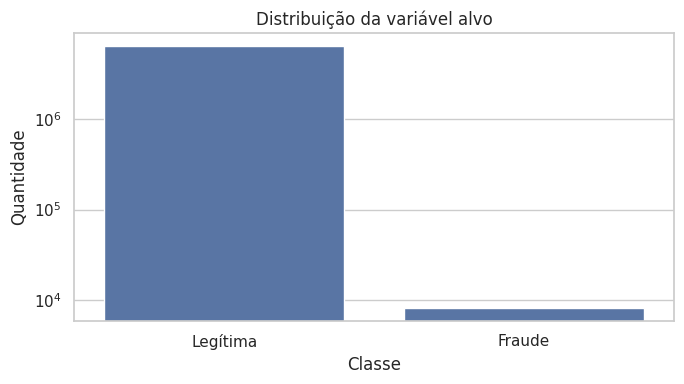

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Legítima", "Fraude"])
plt.yscale("log")
plt.tight_layout()
plt.show()

### Insight

A distribuição da variável alvo confirma o desbalanceamento extremo.  
Por isso, a modelagem deverá priorizar métricas da classe fraude, como:

- recall;
- precision;
- F1-score;
- AUPRC;
- custo de falso positivo e falso negativo.

Também faz sentido testar a robustez do modelo em diferentes níveis de `imbalance ratio`.

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_real = df["isFraud"]
y_pred_tudo_legitimo = np.zeros(len(df), dtype=int)

print("Baseline: prever tudo como legítimo")
print(f"Acurácia: {accuracy_score(y_real, y_pred_tudo_legitimo):.6f}")
print(f"Precision fraude: {precision_score(y_real, y_pred_tudo_legitimo, zero_division=0):.6f}")
print(f"Recall fraude: {recall_score(y_real, y_pred_tudo_legitimo, zero_division=0):.6f}")
print(f"F1 fraude: {f1_score(y_real, y_pred_tudo_legitimo, zero_division=0):.6f}")

Baseline: prever tudo como legítimo
Acurácia: 0.998709
Precision fraude: 0.000000
Recall fraude: 0.000000
F1 fraude: 0.000000


## 6. Análise dos tipos de transação

Nesta etapa verificamos se todos os tipos de transação têm comportamento semelhante ou se as fraudes se concentram em categorias específicas.

In [12]:
contagem_tipo = df["type"].value_counts().rename_axis("type").reset_index(name="quantidade")
contagem_tipo["percentual"] = contagem_tipo["quantidade"] / len(df)

contagem_tipo

,type,quantidade,percentual
0,CASH_OUT,2237500,0.3517
1,PAYMENT,2151495,0.3381
2,CASH_IN,1399284,0.2199
3,TRANSFER,532909,0.0838
4,DEBIT,41432,0.0065


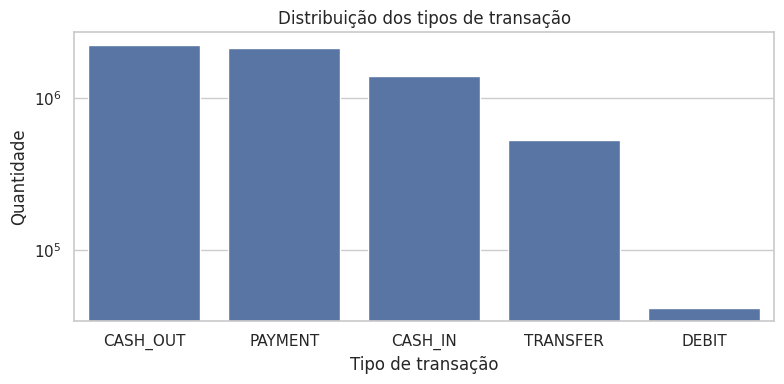

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Distribuição dos tipos de transação")
plt.xlabel("Tipo de transação")
plt.ylabel("Quantidade")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [14]:
fraude_por_tipo = (
    df.groupby("type")
      .agg(
          total=("isFraud", "size"),
          fraudes=("isFraud", "sum"),
          taxa_fraude=("isFraud", "mean"),
          valor_medio=("amount", "mean"),
          valor_mediano=("amount", "median")
      )
      .sort_values("fraudes", ascending=False)
)

fraude_por_tipo

,total,fraudes,taxa_fraude,valor_medio,valor_mediano
type,,,,,
CASH_OUT,2237500,4116,0.0018,"176,273.9643","147,072.1850"
TRANSFER,532909,4097,0.0077,"910,647.0096","486,308.3900"
CASH_IN,1399284,0,0.0000,"168,920.2420","143,427.7100"
DEBIT,41432,0,0.0000,"5,483.6653","3,048.9900"
PAYMENT,2151495,0,0.0000,"13,057.6047","9,482.1900"


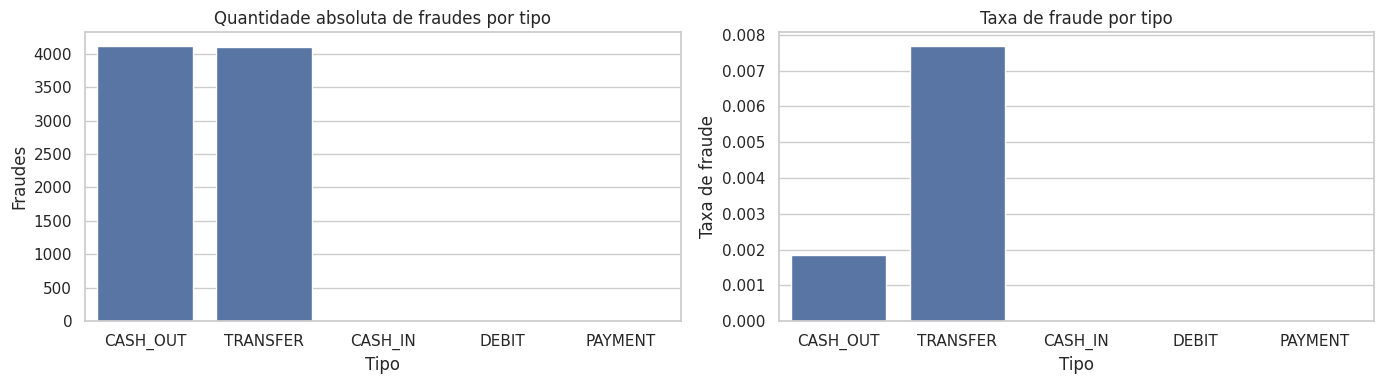

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=fraude_por_tipo.reset_index(),
    x="type",
    y="fraudes",
    ax=axes[0]
)
axes[0].set_title("Quantidade absoluta de fraudes por tipo")
axes[0].set_xlabel("Tipo")
axes[0].set_ylabel("Fraudes")

sns.barplot(
    data=fraude_por_tipo.reset_index(),
    x="type",
    y="taxa_fraude",
    ax=axes[1]
)
axes[1].set_title("Taxa de fraude por tipo")
axes[1].set_xlabel("Tipo")
axes[1].set_ylabel("Taxa de fraude")

plt.tight_layout()
plt.show()

### Insight

A análise por `type` deve orientar tanto a baseline quanto o pré-processamento.

Uma baseline interpretável pode ser construída usando uma regra simples, por exemplo:

> considerar como suspeitas transações dos tipos `TRANSFER` e `CASH_OUT` acima de determinado limiar de valor.

Essa baseline será útil para verificar se modelos mais complexos realmente agregam valor.

## 7. Análise da variável `amount`

A variável `amount` representa o valor da transação.

Em problemas de fraude, valores extremos podem ser informativos, mas também podem dificultar a modelagem caso a distribuição seja muito assimétrica.

In [16]:
df["amount"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("amount")

,amount
count,"6,362,620.0000"
mean,"179,861.9035"
std,"603,858.2315"
min,0.0000
1%,449.4676
5%,"2,224.0995"
25%,"13,389.5700"
50%,"74,871.9400"
75%,"208,721.4775"
95%,"518,634.1965"


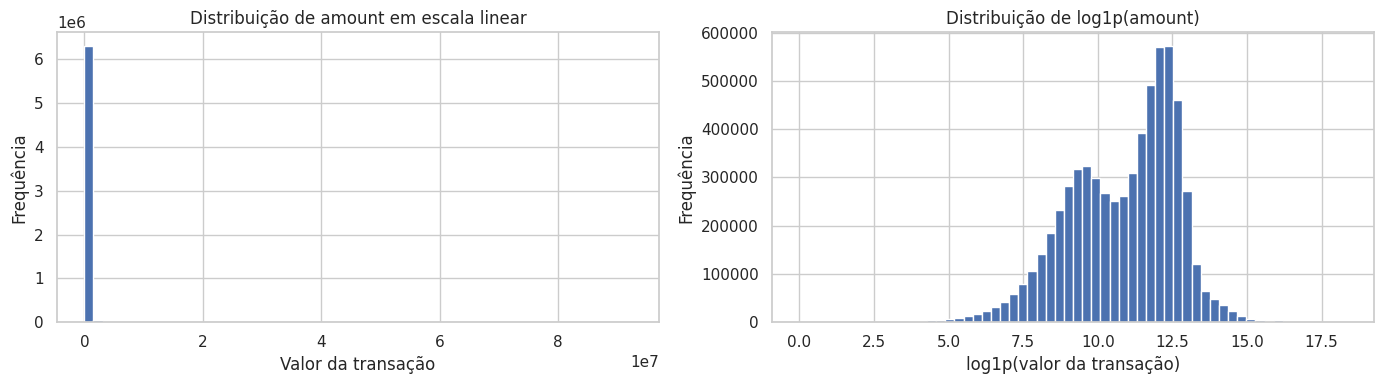

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["amount"].hist(bins=60, ax=axes[0])
axes[0].set_title("Distribuição de amount em escala linear")
axes[0].set_xlabel("Valor da transação")
axes[0].set_ylabel("Frequência")

np.log1p(df["amount"]).hist(bins=60, ax=axes[1])
axes[1].set_title("Distribuição de log1p(amount)")
axes[1].set_xlabel("log1p(valor da transação)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [18]:
resumo_amount_classe = (
    df.groupby("isFraud")["amount"]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
      .rename(index={0: "Legítima", 1: "Fraude"})
)

resumo_amount_classe

,count,mean,std,min,25%,50%,75%,95%,99%,max
isFraud,,,,,,,,,,
Legítima,"6,354,407.0000","178,197.0417","596,236.9813",0.0100,"13,368.3950","74,684.7200","208,364.7600","515,610.4230","1,586,064.1734","92,445,516.6400"
Fraude,"8,213.0000","1,467,967.2991","2,404,252.9472",0.0000,"127,091.3300","441,423.4400","1,517,771.4800","8,006,429.0400","10,000,000.0000","10,000,000.0000"


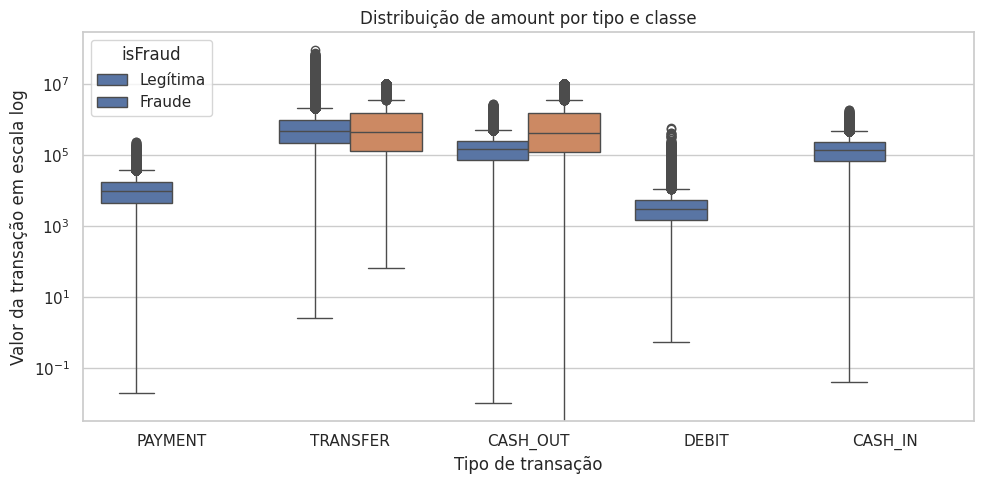

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="type", y="amount", hue="isFraud")
plt.yscale("log")
plt.title("Distribuição de amount por tipo e classe")
plt.xlabel("Tipo de transação")
plt.ylabel("Valor da transação em escala log")
plt.legend(title="isFraud", labels=["Legítima", "Fraude"])
plt.tight_layout()
plt.show()

### Decisão para o próximo notebook

A transformação `log1p(amount)` deve ser considerada no pré-processamento, pois reduz a assimetria e pode ajudar modelos sensíveis à escala, como Regressão Logística.

Para modelos baseados em árvores, a transformação pode não ser obrigatória, mas ainda pode facilitar visualizações e interpretação.

## 8. Análise das variáveis de saldo

As variáveis de saldo são importantes, mas exigem cuidado.

Colunas analisadas:

- `oldbalanceOrg`
- `newbalanceOrig`
- `oldbalanceDest`
- `newbalanceDest`

Essas variáveis podem conter padrões úteis, mas também podem gerar avaliação otimista caso capturem diretamente regras do simulador ou informações posteriores à transação.

In [20]:
colunas_saldo = [
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]

df[colunas_saldo].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,95%,99%,max
oldbalanceOrg,"6,362,620.0000","833,883.1041","2,888,242.6730",0.0000,0.0000,"14,208.0000","107,315.1750","5,823,702.2785","16,027,256.1337","59,585,040.3700"
newbalanceOrig,"6,362,620.0000","855,113.6686","2,924,048.5030",0.0000,0.0000,0.0000,"144,258.4100","5,980,262.3365","16,176,160.5580","49,585,040.3700"
oldbalanceDest,"6,362,620.0000","1,100,701.6665","3,399,180.1130",0.0000,0.0000,"132,705.6650","943,036.7075","5,147,229.7135","12,371,819.1548","356,015,889.3500"
newbalanceDest,"6,362,620.0000","1,224,996.3982","3,674,128.9421",0.0000,0.0000,"214,661.4400","1,111,909.2500","5,515,715.9035","13,137,866.9410","356,179,278.9200"


In [21]:
# Proporção de zeros em cada variável de saldo
zeros_saldo = (df[colunas_saldo] == 0).mean().sort_values(ascending=False)

pd.DataFrame({
    "coluna": zeros_saldo.index,
    "proporcao_zeros": zeros_saldo.values
})

,coluna,proporcao_zeros
0,newbalanceOrig,0.5673
1,oldbalanceDest,0.4250
2,newbalanceDest,0.3834
3,oldbalanceOrg,0.3304


In [22]:
# Diferenças de saldo esperadas.
# Para origem, uma regra intuitiva seria:
# oldbalanceOrg - amount ≈ newbalanceOrig
#
# Para destino, uma regra intuitiva seria:
# oldbalanceDest + amount ≈ newbalanceDest
#
# O objetivo aqui é apenas investigar inconsistências lógicas,
# não assumir que todas são erros do dataset.
#
# Para economizar memória, calculamos as séries separadamente em vez de copiar todo o DataFrame.

TOLERANCIA = 1e-2

erro_saldo_origem = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
erro_saldo_destino = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

inconsistencia_origem = erro_saldo_origem.abs() > TOLERANCIA
inconsistencia_destino = erro_saldo_destino.abs() > TOLERANCIA

resumo_inconsistencias = pd.DataFrame({
    "variavel": ["Origem", "Destino"],
    "quantidade_inconsistente": [
        inconsistencia_origem.sum(),
        inconsistencia_destino.sum()
    ],
    "percentual_inconsistente": [
        inconsistencia_origem.mean(),
        inconsistencia_destino.mean()
    ]
})

resumo_inconsistencias

,variavel,quantidade_inconsistente,percentual_inconsistente
0,Origem,5077691,0.7981
1,Destino,4188647,0.6583


In [23]:
# Taxa de inconsistência por classe
taxa_inconsistencia_classe = pd.DataFrame({
    "isFraud": df["isFraud"],
    "inconsistencia_origem": inconsistencia_origem,
    "inconsistencia_destino": inconsistencia_destino,
    "erro_saldo_origem": erro_saldo_origem,
    "erro_saldo_destino": erro_saldo_destino,
})

taxa_inconsistencia_classe = (
    taxa_inconsistencia_classe
    .groupby("isFraud")
    .agg(
        taxa_inconsistencia_origem=("inconsistencia_origem", "mean"),
        taxa_inconsistencia_destino=("inconsistencia_destino", "mean"),
        erro_origem_mediano=("erro_saldo_origem", "median"),
        erro_destino_mediano=("erro_saldo_destino", "median")
    )
    .rename(index={0: "Legítima", 1: "Fraude"})
)

taxa_inconsistencia_classe

,taxa_inconsistencia_origem,taxa_inconsistencia_destino,erro_origem_mediano,erro_destino_mediano
isFraud,,,,
Legítima,0.7991,0.6584,"-69,049.3100","3,500.6800"
Fraude,0.0055,0.5650,0.0000,"2,231.4600"


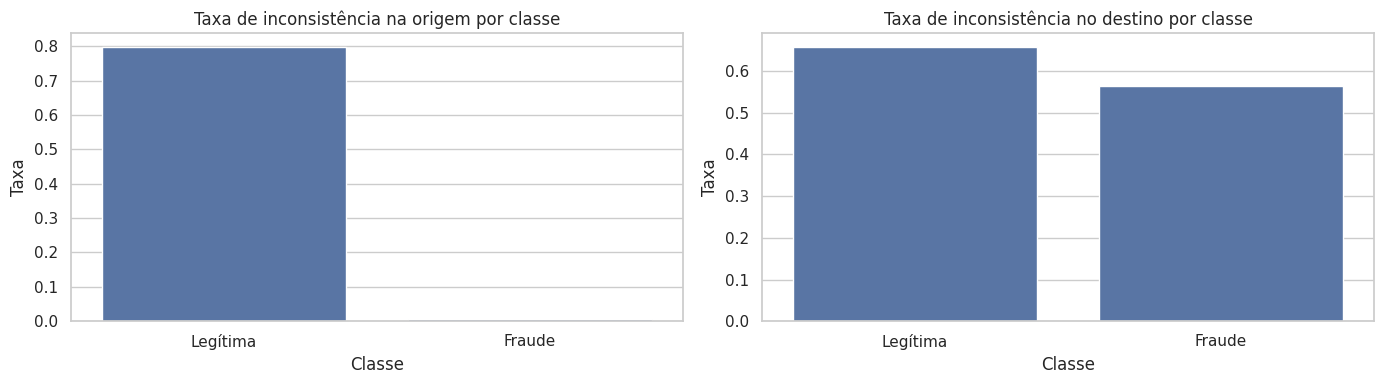

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_incons_origem = pd.DataFrame({
    "isFraud": df["isFraud"],
    "inconsistencia_origem": inconsistencia_origem
}).groupby("isFraud", as_index=False)["inconsistencia_origem"].mean()

plot_incons_destino = pd.DataFrame({
    "isFraud": df["isFraud"],
    "inconsistencia_destino": inconsistencia_destino
}).groupby("isFraud", as_index=False)["inconsistencia_destino"].mean()

sns.barplot(
    data=plot_incons_origem,
    x="isFraud",
    y="inconsistencia_origem",
    ax=axes[0]
)
axes[0].set_title("Taxa de inconsistência na origem por classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Taxa")
axes[0].set_xticklabels(["Legítima", "Fraude"])

sns.barplot(
    data=plot_incons_destino,
    x="isFraud",
    y="inconsistencia_destino",
    ax=axes[1]
)
axes[1].set_title("Taxa de inconsistência no destino por classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Taxa")
axes[1].set_xticklabels(["Legítima", "Fraude"])

plt.tight_layout()
plt.show()

### Decisão para o próximo notebook

As inconsistências de saldo não devem ser simplesmente descartadas sem análise.  
Elas podem representar:

- comportamento do simulador;
- regras internas de transação;
- padrões associados à fraude;
- ou risco de vazamento, caso revelem informação posterior à decisão.

No pré-processamento, podemos criar variáveis derivadas como `erro_saldo_origem` e `erro_saldo_destino`, mas será necessário avaliar com cuidado se elas geram resultados artificiais.

## 9. Avaliação da coluna `isFlaggedFraud`

A coluna `isFlaggedFraud` funciona como uma sinalização interna do dataset.

Ela não será usada como variável principal de treino, porque pode representar uma regra pronta do simulador e criar risco de vazamento ou comparação injusta.

Mesmo assim, é útil avaliá-la como uma baseline simples.

In [25]:
matriz_flag = confusion_matrix(df["isFraud"], df["isFlaggedFraud"])

pd.DataFrame(
    matriz_flag,
    index=["Real legítima", "Real fraude"],
    columns=["Prevista legítima", "Prevista fraude"]
)

,Prevista legítima,Prevista fraude
Real legítima,6354407,0
Real fraude,8197,16


In [26]:
print(classification_report(
    df["isFraud"],
    df["isFlaggedFraud"],
    target_names=["Legítima", "Fraude"],
    zero_division=0
))

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00   6354407
      Fraude       1.00      0.00      0.00      8213

    accuracy                           1.00   6362620
   macro avg       1.00      0.50      0.50   6362620
weighted avg       1.00      1.00      1.00   6362620



In [27]:
flag_summary = (
    df.groupby("isFlaggedFraud")
      .agg(
          total=("isFraud", "size"),
          fraudes=("isFraud", "sum"),
          taxa_fraude=("isFraud", "mean"),
          valor_medio=("amount", "mean"),
          valor_minimo=("amount", "min"),
          valor_maximo=("amount", "max")
      )
)

flag_summary

,total,fraudes,taxa_fraude,valor_medio,valor_minimo,valor_maximo
isFlaggedFraud,,,,,,
0,6362604,8197,0.0013,"179,850.1304",0.0000,"92,445,516.6400"
1,16,16,1.0000,"4,861,597.7306","353,874.2200","10,000,000.0000"


### Insight

A coluna `isFlaggedFraud` costuma apresentar altíssima precisão quando sinaliza uma fraude, mas baixo recall, pois sinaliza poucas transações.

Por isso, ela será usada apenas como comparação/baseline, não como feature principal do modelo.

## 10. Análise dos identificadores `nameOrig` e `nameDest`

As colunas `nameOrig` e `nameDest` são identificadores de origem e destino.

Usá-las diretamente no modelo é problemático porque:

- possuem alta cardinalidade;
- podem gerar overfitting;
- podem memorizar entidades em vez de aprender padrões gerais;
- podem dificultar a inferência em novos clientes ou destinos.

Nesta EDA, avaliamos apenas a cardinalidade e repetição.

In [28]:
ids_resumo = pd.DataFrame({
    "coluna": ["nameOrig", "nameDest"],
    "valores_unicos": [df["nameOrig"].nunique(), df["nameDest"].nunique()],
    "percentual_unico": [df["nameOrig"].nunique() / len(df), df["nameDest"].nunique() / len(df)]
})

ids_resumo

,coluna,valores_unicos,percentual_unico
0,nameOrig,6353307,0.9985
1,nameDest,2722362,0.4279


In [29]:
origem_repeticoes = df["nameOrig"].value_counts()
destino_repeticoes = df["nameDest"].value_counts()

print("Top 10 origens mais frequentes:")
display(origem_repeticoes.head(10).to_frame("quantidade"))

print("Top 10 destinos mais frequentes:")
display(destino_repeticoes.head(10).to_frame("quantidade"))

Top 10 origens mais frequentes:


,quantidade
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


Top 10 destinos mais frequentes:


,quantidade
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C1789550256,99
C451111351,99
C1360767589,98


In [30]:
# Fraudes por frequência de destinos mais recorrentes.
# Esta análise é exploratória e não significa que usaremos o ID diretamente no modelo.
top_destinos = destino_repeticoes.head(20).index

df_top_destinos = (
    df[df["nameDest"].isin(top_destinos)]
    .groupby("nameDest")
    .agg(
        total=("isFraud", "size"),
        fraudes=("isFraud", "sum"),
        taxa_fraude=("isFraud", "mean")
    )
    .sort_values("total", ascending=False)
)

df_top_destinos

,total,fraudes,taxa_fraude
nameDest,,,
C1286084959,113,0,0.0000
C985934102,109,0,0.0000
C665576141,105,0,0.0000
C2083562754,102,0,0.0000
C248609774,101,0,0.0000
C1590550415,101,0,0.0000
C1789550256,99,0,0.0000
C451111351,99,0,0.0000
C1360767589,98,0,0.0000


### Decisão para o próximo notebook

No pré-processamento, a decisão inicial será remover `nameOrig` e `nameDest` do modelo principal.

Como alternativa futura, podem ser criadas features agregadas, como frequência de destino ou histórico de transações por entidade, mas isso exige cuidado para não usar informação do futuro.

## 11. Análise temporal com `step`

A coluna `step` representa o tempo da simulação.

Ela pode ser útil para verificar concentração de fraudes ao longo do tempo e também para definir uma separação temporal entre treino, validação e teste.

In [31]:
df["step"].describe().to_frame("step")

,step
count,"6,362,620.0000"
mean,243.3972
std,142.3320
min,1.0000
25%,156.0000
50%,239.0000
75%,335.0000
max,743.0000


In [32]:
fraude_por_step = (
    df.groupby("step")
      .agg(
          total=("isFraud", "size"),
          fraudes=("isFraud", "sum"),
          taxa_fraude=("isFraud", "mean"),
          valor_medio=("amount", "mean")
      )
      .reset_index()
)

fraude_por_step.head()

,step,total,fraudes,taxa_fraude,valor_medio
0,1,2708,16,0.0059,"105,402.2087"
1,2,1014,8,0.0079,"84,735.3097"
2,3,552,4,0.0072,"78,430.9500"
3,4,565,10,0.0177,"129,044.2984"
4,5,665,6,0.0090,"68,493.3680"


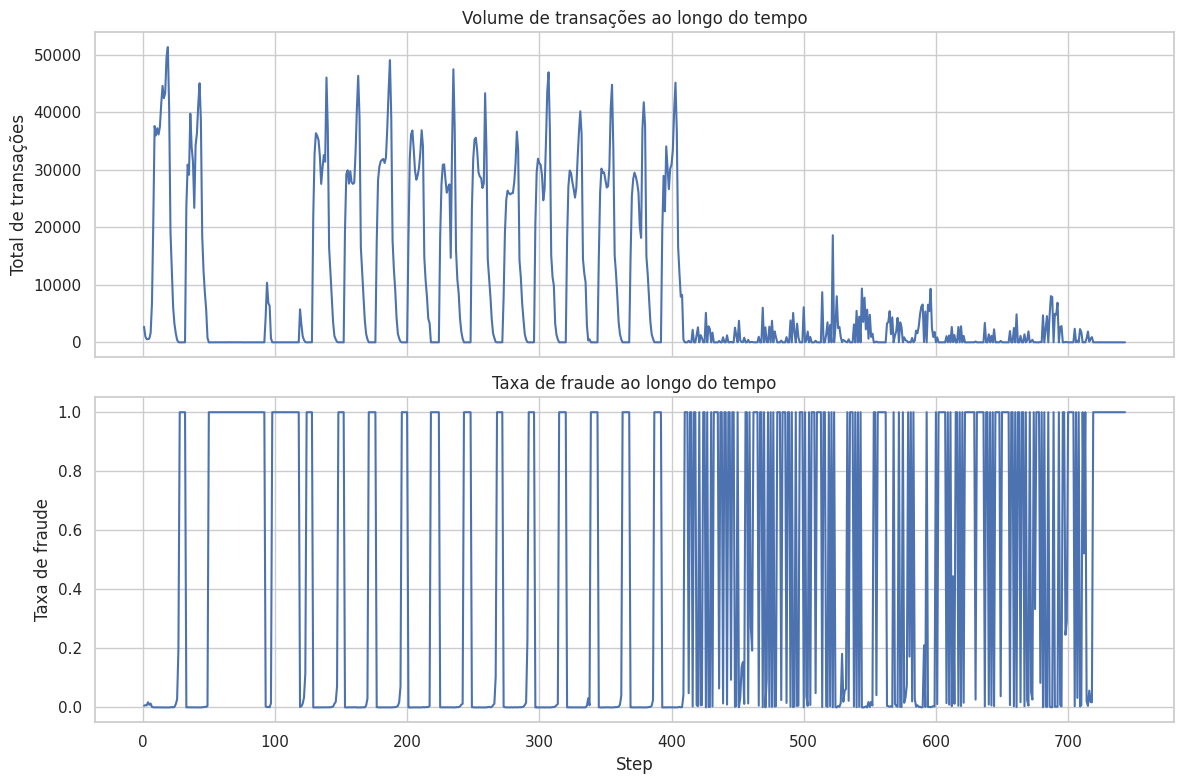

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(fraude_por_step["step"], fraude_por_step["total"])
axes[0].set_title("Volume de transações ao longo do tempo")
axes[0].set_ylabel("Total de transações")

axes[1].plot(fraude_por_step["step"], fraude_por_step["taxa_fraude"])
axes[1].set_title("Taxa de fraude ao longo do tempo")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Taxa de fraude")

plt.tight_layout()
plt.show()

In [34]:
# Análise agregada por dia simulado, considerando que cada step representa 1 hora.
# Para economizar memória, calculamos a série de dia simulado separadamente.
dia_simulado = (df["step"] // 24).astype(int)

fraude_por_dia = (
    pd.DataFrame({
        "dia_simulado": dia_simulado,
        "isFraud": df["isFraud"],
        "amount": df["amount"]
    })
    .groupby("dia_simulado")
    .agg(
        total=("isFraud", "size"),
        fraudes=("isFraud", "sum"),
        taxa_fraude=("isFraud", "mean"),
        valor_medio=("amount", "mean")
    )
    .reset_index()
)

fraude_por_dia.head()

,dia_simulado,total,fraudes,taxa_fraude,valor_medio
0,0,571039,265,0.0005,"160,654.0054"
1,1,452761,305,0.0007,"157,014.1132"
2,2,6749,306,0.0453,"137,527.7274"
3,3,21904,272,0.0124,"143,893.7148"
4,4,12995,244,0.0188,"129,752.7548"


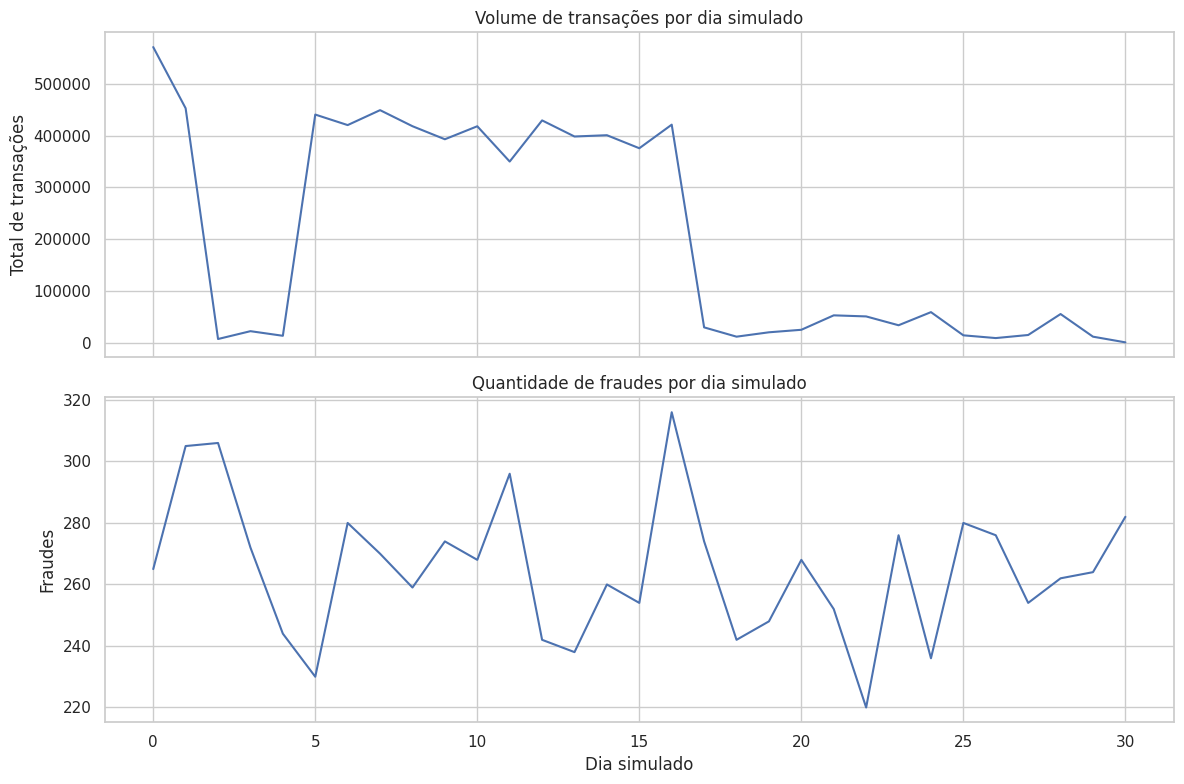

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(fraude_por_dia["dia_simulado"], fraude_por_dia["total"])
axes[0].set_title("Volume de transações por dia simulado")
axes[0].set_ylabel("Total de transações")

axes[1].plot(fraude_por_dia["dia_simulado"], fraude_por_dia["fraudes"])
axes[1].set_title("Quantidade de fraudes por dia simulado")
axes[1].set_xlabel("Dia simulado")
axes[1].set_ylabel("Fraudes")

plt.tight_layout()
plt.show()

### Decisão para o próximo notebook

A separação temporal deve ser considerada no pré-processamento.

Em vez de usar apenas divisão aleatória, uma divisão mais realista seria:

- treino: steps mais antigos;
- validação: steps intermediários;
- teste: steps mais recentes.

Isso simula melhor um cenário real, em que o modelo é treinado com dados passados e aplicado em transações futuras.

## 12. Correlação entre variáveis numéricas

A correlação linear ajuda a observar relações simples entre variáveis numéricas.

Entretanto, ausência de correlação linear forte com `isFraud` não significa ausência de relação preditiva.  
Modelos não lineares, como Random Forest e XGBoost, podem capturar interações mais complexas.

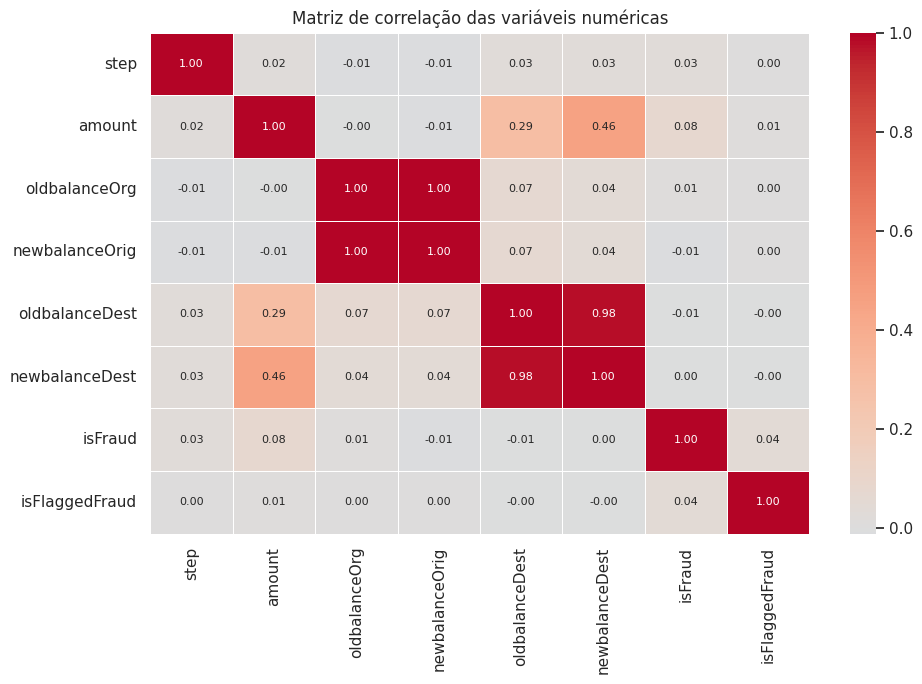

In [36]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

In [37]:
corr_isfraud = corr["isFraud"].sort_values(ascending=False).to_frame("correlacao_com_isFraud")
corr_isfraud

,correlacao_com_isFraud
isFraud,1.0000
amount,0.0767
isFlaggedFraud,0.0441
step,0.0316
oldbalanceOrg,0.0102
newbalanceDest,0.0005
oldbalanceDest,-0.0059
newbalanceOrig,-0.0081


### Insight

A correlação linear tende a ser limitada para esse problema.

O resultado reforça a necessidade de comparar:

- baseline simples por regra;
- Regressão Logística como baseline supervisionado;
- modelos não lineares, como Random Forest e XGBoost;
- estratégias de threshold e tratamento de desbalanceamento.

## 13. Síntese dos principais achados da EDA

Esta seção resume as decisões que serão levadas para o próximo notebook.

In [38]:
resumo_eda = {
    "total_registros": len(df),
    "total_colunas": df.shape[1],
    "total_fraudes": int(qtd_fraudes),
    "taxa_fraude": qtd_fraudes / len(df),
    "imbalance_ratio_legitimas_por_fraude": imbalance_ratio,
    "duplicatas": int(duplicatas),
    "total_nulos": int(df.isna().sum().sum()),
    "tipos_transacao": ", ".join(df["type"].unique()),
    "fraudes_por_tipo": fraude_por_tipo["fraudes"].to_dict(),
    "taxa_fraude_por_tipo": fraude_por_tipo["taxa_fraude"].to_dict(),
    "flags_fraude_ativadas": int(df["isFlaggedFraud"].sum()),
    "inconsistencia_origem_percentual": float(inconsistencia_origem.mean()),
    "inconsistencia_destino_percentual": float(inconsistencia_destino.mean()),
}

resumo_eda

{'total_registros': 6362620,
 'total_colunas': 11,
 'total_fraudes': 8213,
 'taxa_fraude': np.float64(0.001290820448180152),
 'imbalance_ratio_legitimas_por_fraude': np.float64(773.7010836478753),
 'duplicatas': 0,
 'total_nulos': 0,
 'tipos_transacao': 'PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN',
 'fraudes_por_tipo': {'CASH_OUT': 4116,
  'TRANSFER': 4097,
  'CASH_IN': 0,
  'DEBIT': 0,
  'PAYMENT': 0},
 'taxa_fraude_por_tipo': {'CASH_OUT': 0.0018395530726256983,
  'TRANSFER': 0.007687991758442811,
  'CASH_IN': 0.0,
  'DEBIT': 0.0,
  'PAYMENT': 0.0},
 'flags_fraude_ativadas': 16,
 'inconsistencia_origem_percentual': 0.7980503314672258,
 'inconsistencia_destino_percentual': 0.6583211004271825}

In [41]:
decisoes_eda = pd.DataFrame({
    "Item": [
        "isFlaggedFraud",
        "nameOrig",
        "nameDest",
        "type",
        "amount",
        "saldos",
        "step",
        "SMOTE"
    ],
    "Decisão": [
        "Não usar como feature principal",
        "Remover do modelo principal",
        "Remover do modelo principal",
        "Codificar com One-Hot Encoding",
        "Criar log_amount com log1p",
        "Criar erros e flags de inconsistência",
        "Avaliar uso em divisão temporal",
        "Aplicar apenas depois da separação treino/teste"
    ],
    "Justificativa": [
        "Pode causar vazamento e possui recall muito baixo",
        "Alta cardinalidade e pouco reaproveitamento",
        "Alta cardinalidade",
        "Fraudes concentradas em TRANSFER e CASH_OUT",
        "Distribuição muito assimétrica",
        "Podem conter informação útil, mas exigem cuidado",
        "Simula melhor cenário real de transações futuras",
        "Evita vazamento de informação"
    ]
})

decisoes_eda

,Item,Decisão,Justificativa
0,isFlaggedFraud,Não usar como feature principal,Pode causar vazamento e possui recall muito baixo
1,nameOrig,Remover do modelo principal,Alta cardinalidade e pouco reaproveitamento
2,nameDest,Remover do modelo principal,Alta cardinalidade
3,type,Codificar com One-Hot Encoding,Fraudes concentradas em TRANSFER e CASH_OUT
4,amount,Criar log_amount com log1p,Distribuição muito assimétrica
5,saldos,Criar erros e flags de inconsistência,"Podem conter informação útil, mas exigem cuidado"
6,step,Avaliar uso em divisão temporal,Simula melhor cenário real de transações futuras
7,SMOTE,Aplicar apenas depois da separação treino/teste,Evita vazamento de informação


### Conclusões da EDA

1. O dataset apresenta desbalanceamento extremo, tornando a acurácia inadequada como métrica principal.
2. As fraudes se concentram em tipos específicos de transação, principalmente `TRANSFER` e `CASH_OUT`.
3. A variável `amount` é bastante assimétrica, então `log1p(amount)` deve ser considerada.
4. `isFlaggedFraud` não deve ser usada como feature principal, mas pode servir como baseline de comparação.
5. `nameOrig` e `nameDest` têm alta cardinalidade e devem ser removidas do modelo principal.
6. As variáveis de saldo e seus erros derivados podem ser informativos, mas exigem cuidado por risco de vazamento.
7. A variável `step` pode ser usada para análise temporal e para criar uma separação treino/validação/teste mais realista.
8. O próximo notebook deve transformar essas decisões em um pipeline de pré-processamento reprodutível.

## 14. Recomendações para o notebook de pré-processamento

Com base nesta EDA, o próximo notebook deve implementar:

### Remoção inicial de colunas

- Remover `isFlaggedFraud` do conjunto de features principal;
- Remover `nameOrig` e `nameDest` do modelo principal.

### Engenharia de atributos

- Criar `log_amount = log1p(amount)`;
- Criar `erro_saldo_origem`;
- Criar `erro_saldo_destino`;
- Criar flags de inconsistência de saldo;
- Codificar `type` com One-Hot Encoding;
- Avaliar uso de `step` e `dia_simulado`.

### Separação dos dados

- Preferir divisão temporal baseada em `step`;
- Manter a proporção da classe fraude monitorada em treino, validação e teste;
- Evitar qualquer técnica de balanceamento antes da separação dos dados.

### Cuidados com desbalanceamento

- Não aplicar SMOTE no dataset inteiro;
- Testar `class_weight`, `scale_pos_weight` e ajuste de threshold no notebook de modelagem;
- Registrar o imbalance ratio em cada divisão.

### Saída esperada

O notebook de pré-processamento deverá gerar datasets prontos para modelagem, por exemplo:

- `treino_processado.parquet`;
- `validacao_processado.parquet`;
- `teste_processado.parquet`.

Esses arquivos serão usados no notebook de modelagem.